* carry digit - when you add "under line" and the digits e.g. 6+7 equal 13, 1 will be an additional carry digit in the next line

Carry digits can propagate to the left!!

In classical computation we have bit operations with **carry bits**. On the quantum computer we need to take care of the carry qubit

Addition is in binar version. We can always think od implementing modulo 2

## Majority rule (like in a pole) // open cell for better formatting

a b c_in c_out
--------------
0 0 0.    0
0 0 1.    0
0 1 0.    0
0 1 1.    1
1 0 0.    0
1 1 0.    1
1 0 1.    1 
1 1 1.    1

We can easily formulate this into equation


## Majority gate (tricky)

third gate is doubly quantum controlled (upper 2 bits are 1). but it only takes care of the carry bit and not addition. for addition and unmajority we need UMA gate...

## Unmajority gate

It is in general the reversed MAJ, but we need to change the last gate to be controlled on the carry bit not a bit (it is explained by classical AND gate)

## Quantum doublly controlled X - CCX

- Is a block matrix.
- To build this we need 6 controlled gates.
- We have additional gate which is a phase rotation (on Bloch sphere)


## CCX (Toffoli) gate decomposition

We need to propagate both ways (not only left but also right) to take care of the carry bit :))

In [46]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

## Task:

Code quantum addition by MAJ an UMA gates from CX and CCX
and drawing a circuit.

## GATES

In [47]:
def create_maj_gate():
    maj_qc = QuantumCircuit(3, name="MAJ")
    maj_qc.cx(2, 1) # CNOT: control 2, target 1
    maj_qc.cx(2, 0) # CNOT: control 2, target 0
    maj_qc.ccx(0, 1, 2)  # Toffoli: controls 0 and 1, target 2
    
    return maj_qc.to_instruction()

#test
maj_gate = create_maj_gate()
qc = QuantumCircuit(3)
qc.append(maj_gate, [0, 1, 2])
print(qc.draw())

     ┌──────┐
q_0: ┤0     ├
     │      │
q_1: ┤1 MAJ ├
     │      │
q_2: ┤2     ├
     └──────┘


In [48]:
def create_uma_gate():
    uma_qc = QuantumCircuit(3, name="UMA")
    uma_qc.ccx(0, 1, 2) # Toffoli: control 0 and 1, target 2
    uma_qc.cx(2, 0)     # CNOT: control 2, target 0
    uma_qc.cx(0, 1)     # CNOT: control 0, target 1 !!

    return uma_qc.to_instruction()

#test
uma_gate = create_uma_gate()
qc = QuantumCircuit(3)
qc.append(uma_gate, [0, 1, 2])
print(qc.draw())

     ┌──────┐
q_0: ┤0     ├
     │      │
q_1: ┤1 UMA ├
     │      │
q_2: ┤2     ├
     └──────┘


## CIRCUIT

In [58]:
def create_circuit_add(val_a=0, val_b=0, define_c_in=0):

    a = QuantumRegister(6, 'a')
    b = QuantumRegister(6, 'b')
    c = QuantumRegister(1, 'c')
    cr = ClassicalRegister(6, 'sum_measurement')
    
    qc = QuantumCircuit(c,a,b,cr)

    # ------------------------------------------------------
    bin_a = format(val_a, '06b')[::-1]
    bin_b = format(val_b, '06b')[::-1]
    
    for i in range(6):
        if bin_a[i] == '1': qc.x(a[i])
        if bin_b[i] == '1': qc.x(b[i])

    if define_c_in and (define_c_in == 1):
        qc.x(c[0])  # else default 0
    if define_c_in > 1:
        raise ValueError("define_c_in should be either 0 or 1.")
    qc.barrier()
    # -------------------------------------------------------

    maj_gate = create_maj_gate()
    uma_gate = create_uma_gate()

    # 1. MAJ gates 
    qc.append(maj_gate, [c[0], b[0], a[0]]) 
    qc.append(maj_gate, [a[0], b[1], a[1]])
    qc.append(maj_gate, [a[1], b[2], a[2]])
    qc.append(maj_gate, [a[2], b[3], a[3]])
    qc.append(maj_gate, [a[3], b[4], a[4]])
    qc.append(maj_gate, [a[4], b[5], a[5]])

    qc.barrier()

    # 2. UMA gates 
    qc.append(uma_gate, [a[4], b[5], a[5]])
    qc.append(uma_gate, [a[3], b[4], a[4]])
    qc.append(uma_gate, [a[2], b[3], a[3]])
    qc.append(uma_gate, [a[1], b[2], a[2]])
    qc.append(uma_gate, [a[0], b[1], a[1]])
    qc.append(uma_gate, [c[0], b[0], a[0]])
    
    qc.barrier()

    qc.measure(b, cr) #sum

    return qc

In [59]:
def run_and_plot(a,b,c,circuit_name ,backend=AerSimulator(), N=1000):

    circuit = create_circuit_add(val_a = a, val_b = b, define_c_in = c)
    transpiled_circuit = transpile(circuit, backend)
    job = backend.run(transpiled_circuit, shots=N)
    result = job.result()
    counts = result.get_counts(transpiled_circuit)

    #read-out (binray -> decimal)
    bin = list(counts.keys())[0]
    dec = int(bin, 2)
    print(f"Want to add {a} and {b} (decimal)")
    print(f"Results for circuit '{circuit_name}': {counts} for decimal")
    print(f"Measured Quantum Output (binary): {bin}")
    print(f"Measured Quantum Output (decimal): {dec}")


    fig = circuit.draw("mpl")
    
    return counts, fig

Want to add 19 and 27 (decimal)
Results for circuit 'ADD': {'101110': 1000} for decimal
Measured Quantum Output (binary): 101110
Measured Quantum Output (decimal): 46


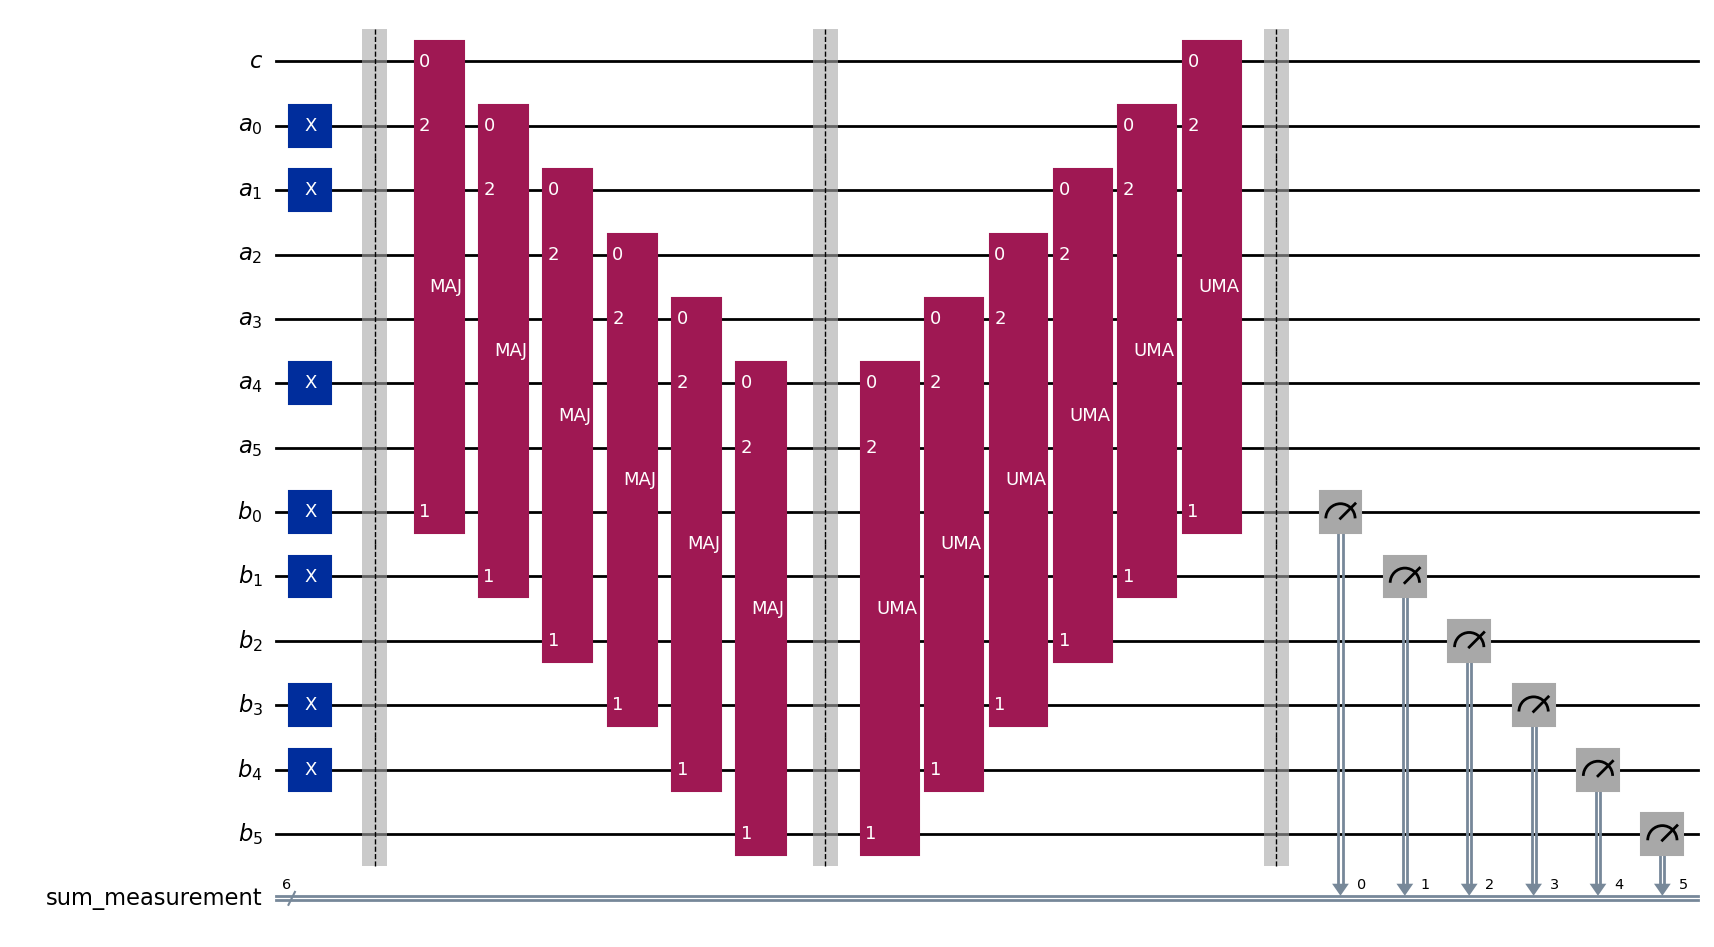

In [66]:
cunts, fig_add = run_and_plot(19, 27, 0, "ADD")
fig_add